# Post-Evaluation & Selection of Synthetic QUIDA Datasets

Evaluate the **12 synthetic datasets** (3 generation methods x 4 sensor combinations) produced from the
QUIDA multimodal fall-detection data, and produce a **scientifically defensible ranking** to decide which
generated dataset(s) proceed to the next research stage.

**Generation methods:** Jittering, VAE, TimeGAN
**Sensor combinations:** IMU, IMU+IR, IMU+Radar, IMU+IR+Radar

**Two clearly separated analyses (never mixed):**

* **A. Controlled-size comparison** — fair method-vs-method comparison *within each sensor combination* at a
  common synthetic sample size, repeated over many random subsamples.
* **B. Full-size evaluation** — how good each generated dataset is *at the quantity it actually provides*.

**Evaluation dimensions (grouped to avoid double-counting correlated metrics):**

* *Fidelity* — MMD (RBF), Wasserstein, multivariate Hellinger, correlation/dependency preservation.
* *Diversity / coverage* — coverage, density, nearest-neighbour diversity, variance preservation.

Scores are built hierarchically (sub-group -> category -> overall) so no dimension dominates merely by
containing more metrics.

---
### Methodological reference

El Emam K, Mosquera L, Fang X, El-Hussuna A. *Utility Metrics for Evaluating Synthetic Health Data
Generation Methods: Validation Study.* JMIR Med Inform. 2022;10(4):e35734.
[doi:10.2196/35734](https://doi.org/10.2196/35734)

This study supports the general practice of using **broad utility metrics** (including MMD, Wasserstein and
Hellinger distance) to **rank competing synthetic-data-generation methods**, and the distinction between
dataset-specific and model-specific utility. In their validation setting the **multivariate Hellinger
distance had a slight advantage for ranking** SDG methods — but MMD, Wasserstein, cluster analysis,
propensity-MSE and prediction-MSE also performed well, so Hellinger is **not** treated here as universally
dominant.

**Scope caveat:** El Emam et al. evaluated *structured health datasets* under a specific workload. It does
**not** validate any metric specifically for QUIDA, multimodal sensor time-series, or fall detection. It is
used here only as general methodological support for metric-based ranking of SDG methods.

> **Honest limitation.** The real reference sets here are small (~99 samples). With few real samples and very
> high feature dimensionality (up to ~1900 features), every metric is an *approximation*. This notebook is
> built to be explicit about representation choices and to flag statistical instability rather than hide it.

## 1. Configuration

All tunable parameters live here. Nothing about sample counts, shapes or paths is hard-coded downstream — the notebook inspects the actual files and derives the configuration from them.

In [1]:
from pathlib import Path

# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_DIR = Path("/voc/work/evaluation_and_comparison")

# Synthetic/generated datasets
GENERATED_DATA_DIR = PROJECT_DIR / "generated_data"

# Real/reference datasets
REAL_DATA_DIR = PROJECT_DIR / "real_data"


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42
N_REPEATS = 20


# ============================================================
# REAL DATA FILENAMES
# ============================================================

REAL_NAME_PATTERNS = [
    "{combo}_raw.npy",
    "{combo}.npy",
    "real_{combo}.npy",
    "{combo}_real.npy",
    "{combo}_original.npy",
]


# ============================================================
# METHOD / SENSOR VOCABULARY
# ============================================================

METHOD_PREFIXES = {
    "Jitter": "Jittering",
    "VAE": "VAE",
    "TimeGAN": "TimeGAN",
}

COMBO_LABELS = {
    "X_imu": "IMU",
    "X_imu_ir": "IMU+IR",
    "X_imu_radar": "IMU+Radar",
    "X_imu_ir_radar": "IMU+IR+Radar",
}


# ============================================================
# CONTROLLED SAMPLE SIZE
# ============================================================

CONTROLLED_SAMPLE_SIZE_MODE = "minimum_available"

CUSTOM_SAMPLE_SIZES = {
    # Example:
    # "X_imu": 100,
    # "X_imu_ir": 100,
    # "X_imu_radar": 100,
    # "X_imu_ir_radar": 100,
}


# ============================================================
# SMALL SAMPLE THRESHOLDS
# ============================================================

SMALL_SAMPLE_WARN = 60
SMALL_SAMPLE_MIN = 20


# ============================================================
# CATEGORY WEIGHTS
# ============================================================

CATEGORY_WEIGHTS = {
    "fidelity": 0.50,
    "diversity": 0.50,
}


# ============================================================
# METRIC / REPRESENTATION SETTINGS
# ============================================================

EMB_MAX_DIM = 30
FEAT_CAP = 200
MMD_CAP = 800
DC_K = 5
REDUNDANCY_RHO = 0.80


# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

RESULTS_DIR = PROJECT_DIR / "post_evaluation_output"
FIG_DIR = RESULTS_DIR / "post_evaluation_figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# VALIDATION
# ============================================================

print("=" * 70)
print("POST-EVALUATION CONFIGURATION")
print("=" * 70)

print(f"Project dir      : {PROJECT_DIR}")
print(f"Notebook         : {PROJECT_DIR / 'QUIDA_Synthetic_PostEvaluation.ipynb'}")

print(f"\nGenerated dir    : {GENERATED_DATA_DIR}")
print(f"Generated exists : {GENERATED_DATA_DIR.exists()}")

print(f"Real data dir    : {REAL_DATA_DIR}")
print(f"Real data exists : {REAL_DATA_DIR.exists()}")

if not GENERATED_DATA_DIR.exists():
    raise FileNotFoundError(
        f"Synthetic data directory does not exist:\n{GENERATED_DATA_DIR}"
    )

if not REAL_DATA_DIR.exists():
    raise FileNotFoundError(
        f"Real data directory does not exist:\n{REAL_DATA_DIR}"
    )

generated_files = sorted(GENERATED_DATA_DIR.glob("*.npy"))
real_files = sorted(REAL_DATA_DIR.glob("*.npy"))

print(f"\nGenerated files  : {len(generated_files)}")
for f in generated_files:
    print(f"  - {f.name}")

print(f"\nReal .npy files  : {len(real_files)}")
for f in real_files:
    print(f"  - {f.name}")

print(f"\nResults dir      : {RESULTS_DIR}")
print(f"Figures dir      : {FIG_DIR}")

print(f"\nSEED             : {SEED}")
print(f"N_REPEATS        : {N_REPEATS}")
print(f"Sample mode      : {CONTROLLED_SAMPLE_SIZE_MODE}")

print(f"\nCategory weights : {CATEGORY_WEIGHTS}")

print("\n" + "=" * 70)

POST-EVALUATION CONFIGURATION
Project dir      : /voc/work/evaluation_and_comparison
Notebook         : /voc/work/evaluation_and_comparison/QUIDA_Synthetic_PostEvaluation.ipynb

Generated dir    : /voc/work/evaluation_and_comparison/generated_data
Generated exists : True
Real data dir    : /voc/work/evaluation_and_comparison/real_data
Real data exists : True

Generated files  : 12
  - Jitter_X_imu.npy
  - Jitter_X_imu_ir.npy
  - Jitter_X_imu_ir_radar.npy
  - Jitter_X_imu_radar.npy
  - TimeGAN_X_imu.npy
  - TimeGAN_X_imu_ir.npy
  - TimeGAN_X_imu_ir_radar.npy
  - TimeGAN_X_imu_radar.npy
  - VAE_X_imu.npy
  - VAE_X_imu_ir.npy
  - VAE_X_imu_ir_radar.npy
  - VAE_X_imu_radar.npy

Real .npy files  : 4
  - X_imu_ir_radar_raw.npy
  - X_imu_ir_raw.npy
  - X_imu_radar_raw.npy
  - X_imu_raw.npy

Results dir      : /voc/work/evaluation_and_comparison/post_evaluation_output
Figures dir      : /voc/work/evaluation_and_comparison/post_evaluation_output/post_evaluation_figures

SEED             : 42
N_

## 2. Imports

In [2]:
from __future__ import annotations
import os, json, warnings, itertools
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.covariance import LedoitWolf
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance, friedmanchisquare, kruskal, spearmanr, rankdata

np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 240); pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

FIDELITY_METRICS = ["mmd", "wasserstein", "hellinger", "corr_diff"]
DIVERSITY_METRICS = ["coverage", "density", "nn_ratio", "var_diff"]
ALL_METRICS = FIDELITY_METRICS + DIVERSITY_METRICS
print("Ready. Metrics:", ALL_METRICS)

Ready. Metrics: ['mmd', 'wasserstein', 'hellinger', 'corr_diff', 'coverage', 'density', 'nn_ratio', 'var_diff']


## 3. Dataset discovery

Synthetic files are parsed as `{Method}_{comboKey}.npy`. Real files are then discovered for each combo key by searching the candidate directories with the configured name patterns. **No path is invented** — if a real file is not found the notebook stops and lists exactly where it looked.

In [3]:
def _load(p):
    return np.load(p, allow_pickle=False)

def discover_synthetic(gen_dir):
    if not Path(gen_dir).exists():
        raise FileNotFoundError(f"GENERATED_DATA_DIR does not exist: {gen_dir}. Edit it in the config cell.")
    found = []
    for p in sorted(Path(gen_dir).glob("*.npy")):
        stem = p.stem
        prefix = next((m for m in METHOD_PREFIXES if stem.lower().startswith(m.lower()+"_")), None)
        if prefix is None:
            continue
        combo = stem[len(prefix)+1:]                    # strip "Method_"
        combo_key = next((c for c in COMBO_LABELS if c.lower() == combo.lower()), combo)
        found.append({"path": p, "method": prefix, "method_label": METHOD_PREFIXES[prefix],
                      "combo_key": combo_key, "sensors": COMBO_LABELS.get(combo_key, combo_key)})
    if not found:
        raise FileNotFoundError(
            f"No synthetic .npy matching '{{Method}}_{{combo}}.npy' in {gen_dir}. "
            f"Known method prefixes: {list(METHOD_PREFIXES)}")
    return found

def discover_real(combo_keys):
    search = [Path(REAL_DATA_DIR)] if REAL_DATA_DIR else list(REAL_SEARCH_DIRS)
    real = {}; missing = {}
    for ck in combo_keys:
        hit = None
        for d in search:
            if d is None or not Path(d).exists():
                continue
            for pat in REAL_NAME_PATTERNS:
                cand = Path(d) / pat.format(combo=ck)
                if cand.exists():
                    hit = cand; break
            if hit: break
        if hit: real[ck] = hit
        else:   missing[ck] = [str(Path(d) / p.format(combo=ck)) for d in search if d for p in REAL_NAME_PATTERNS]
    if missing:
        msg = ["Could not locate real data for: " + ", ".join(missing)]
        for ck, tried in missing.items():
            msg.append(f"\n  [{ck}] searched:\n    " + "\n    ".join(tried[:8]) + (" ..." if len(tried) > 8 else ""))
        msg.append("\nSet REAL_DATA_DIR or extend REAL_NAME_PATTERNS in the config cell. No path was invented.")
        raise FileNotFoundError("".join(msg))
    return real

SYNTH = discover_synthetic(GENERATED_DATA_DIR)
COMBO_KEYS = sorted({s["combo_key"] for s in SYNTH})
REAL_FILES = discover_real(COMBO_KEYS)

print(f"Discovered {len(SYNTH)} synthetic datasets across {len(COMBO_KEYS)} sensor combos.")
for ck in COMBO_KEYS:
    print(f"  real[{ck:16s}] <- {REAL_FILES[ck]}")
if len(SYNTH) != 12:
    warnings.warn(f"Expected 12 synthetic datasets, found {len(SYNTH)}. Proceeding with what exists.")

Discovered 12 synthetic datasets across 4 sensor combos.
  real[X_imu           ] <- /voc/work/evaluation_and_comparison/real_data/X_imu_raw.npy
  real[X_imu_ir        ] <- /voc/work/evaluation_and_comparison/real_data/X_imu_ir_raw.npy
  real[X_imu_ir_radar  ] <- /voc/work/evaluation_and_comparison/real_data/X_imu_ir_radar_raw.npy
  real[X_imu_radar     ] <- /voc/work/evaluation_and_comparison/real_data/X_imu_radar_raw.npy


## 4. Dataset metadata table

Every dataset (12 synthetic + real references) is described: shape, sample count, sequence length, feature count, NaN/Inf counts and basic statistics. Nothing is reshaped here.

In [4]:
def describe(name, method, sensors, path, X, kind):
    N, T, F = (X.shape + (None, None))[:3] if X.ndim == 3 else (X.shape[0], None, None)
    return {"kind": kind, "name": name, "generator": method, "sensors": sensors,
            "file": Path(path).name, "shape": str(X.shape), "n_samples": int(X.shape[0]),
            "seq_len": int(T) if T else np.nan, "n_features": int(F) if F else np.nan,
            "n_nan": int(np.isnan(X).sum()), "n_inf": int(np.isinf(X).sum()),
            "min": float(np.nanmin(X)), "max": float(np.nanmax(X)),
            "mean": float(np.nanmean(X)), "std": float(np.nanstd(X))}

RAW_SYNTH, RAW_REAL, meta_rows = {}, {}, []
for ck in COMBO_KEYS:
    Xr = _load(REAL_FILES[ck]); RAW_REAL[ck] = Xr
    meta_rows.append(describe(f"REAL_{ck}", "REAL", COMBO_LABELS.get(ck, ck), REAL_FILES[ck], Xr, "real"))
for s in SYNTH:
    Xs = _load(s["path"]); RAW_SYNTH[(s["method"], s["combo_key"])] = Xs
    meta_rows.append(describe(f"{s['method']}_{s['combo_key']}", s["method_label"], s["sensors"],
                              s["path"], Xs, "synthetic"))

META = pd.DataFrame(meta_rows)
META.to_csv(RESULTS_DIR / "dataset_metadata.csv", index=False)
print("Sample counts differ by design — reported explicitly below.\n")
try: display(META)
except NameError: print(META.to_string(index=False))

Sample counts differ by design — reported explicitly below.



,kind,name,generator,sensors,file,shape,n_samples,seq_len,n_features,n_nan,n_inf,min,max,mean,std
0,real,REAL_X_imu,REAL,IMU,X_imu_raw.npy,"(99, 32, 3)",99,32,3,0,0,-73.3806,72.0936,1.7345,6.3463
1,real,REAL_X_imu_ir,REAL,IMU+IR,X_imu_ir_raw.npy,"(99, 32, 771)",99,32,771,0,0,-73.3806,72.0936,23.9916,2.2740
2,real,REAL_X_imu_ir_radar,REAL,IMU+IR+Radar,X_imu_ir_radar_raw.npy,"(99, 32, 1905)",99,32,1905,0,0,-73.3806,"1,522.9922",18.2452,43.0397
3,real,REAL_X_imu_radar,REAL,IMU+Radar,X_imu_radar_raw.npy,"(99, 32, 1137)",99,32,1137,0,0,-73.3806,"1,522.9922",14.3050,55.3449
4,synthetic,Jitter_X_imu,Jittering,IMU,Jitter_X_imu.npy,"(594, 32, 3)",594,32,3,0,0,-73.7975,72.4183,1.7338,6.3532
5,synthetic,Jitter_X_imu_ir,Jittering,IMU+IR,Jitter_X_imu_ir.npy,"(594, 32, 771)",594,32,771,0,0,-73.9831,72.4496,23.9916,2.2745
6,synthetic,Jitter_X_imu_ir_radar,Jittering,IMU+IR+Radar,Jitter_X_imu_ir_radar.npy,"(495, 32, 1905)",495,32,1905,0,0,-74.1011,"1,526.2913",18.2448,43.0613
7,synthetic,Jitter_X_imu_radar,Jittering,IMU+Radar,Jitter_X_imu_radar.npy,"(594, 32, 1137)",594,32,1137,0,0,-73.9287,"1,526.1647",14.3049,55.3738
8,synthetic,TimeGAN_X_imu,TimeGAN,IMU,TimeGAN_X_imu.npy,"(99, 32, 3)",99,32,3,0,0,-6.9095,13.7381,1.6753,4.5266
9,synthetic,TimeGAN_X_imu_ir,TimeGAN,IMU+IR,TimeGAN_X_imu_ir.npy,"(891, 32, 771)",891,32,771,0,0,-37.5531,30.2135,23.8968,2.2081


## 5. Validation

For every sensor combination the real and synthetic arrays must agree on sequence length and feature count (channel ordering is assumed identical because both derive from the same preprocessing — this is stated, not silently enforced). Incompatible arrays raise an error; non-finite values are imputed with a printed notice rather than silently zeroed.

In [5]:
def clean_finite(name, X):
    nn, ni = int(np.isnan(X).sum()), int(np.isinf(X).sum())
    if nn or ni:
        F = X.shape[-1]; Xf = np.where(np.isfinite(X), X, np.nan)
        fm = np.nan_to_num(np.nanmean(Xf.reshape(-1, F), axis=0))
        ii = np.where(~np.isfinite(Xf)); Xf[ii] = np.take(fm, ii[-1])
        print(f"  ! {name}: imputed {nn} NaN / {ni} Inf with per-channel means (documented, not zeroed)")
        return Xf.astype(np.float32)
    return X.astype(np.float32)

problems = []
for ck in COMBO_KEYS:
    Xr = RAW_REAL[ck]
    if Xr.ndim != 3:
        problems.append(f"real[{ck}] is not 3-D (got {Xr.shape})"); continue
    Tr, Fr = Xr.shape[1], Xr.shape[2]
    RAW_REAL[ck] = clean_finite(f"REAL_{ck}", Xr)
    for m in METHOD_PREFIXES:
        key = (m, ck)
        if key not in RAW_SYNTH: continue
        Xs = RAW_SYNTH[key]
        if Xs.ndim != 3:
            problems.append(f"{m}_{ck} is not 3-D (got {Xs.shape})"); continue
        if Xs.shape[1] != Tr or Xs.shape[2] != Fr:
            problems.append(f"{m}_{ck} shape {Xs.shape} incompatible with real (T={Tr}, F={Fr}) — NOT reshaped")
            continue
        RAW_SYNTH[key] = clean_finite(f"{m}_{ck}", Xs)

if problems:
    raise ValueError("Validation failed (nothing silently reshaped):\n  - " + "\n  - ".join(problems))
print("\nValidation passed: real/synthetic shapes compatible per sensor combination; "
      "channel ordering assumed identical (same preprocessing).")


Validation passed: real/synthetic shapes compatible per sensor combination; channel ordering assumed identical (same preprocessing).


## 6. Real / synthetic pairing (no leakage)

Each synthetic dataset is paired **only** with the real reference of its own sensor combination — never across combinations. The real arrays are never modified.

In [6]:
PAIRS = []
for s in SYNTH:
    ck = s["combo_key"]; key = (s["method"], ck)
    if key not in RAW_SYNTH: continue
    Xs, Xr = RAW_SYNTH[key], RAW_REAL[ck]
    PAIRS.append({"name": f"{s['method']}_{ck}", "method": s["method"], "method_label": s["method_label"],
                  "combo_key": ck, "sensors": s["sensors"], "synth": Xs, "real": Xr,
                  "n_synth": int(Xs.shape[0]), "n_real": int(Xr.shape[0]),
                  "seq_len": int(Xr.shape[1]), "n_feat": int(Xr.shape[2])})
print(f"{len(PAIRS)} real/synthetic pairs (each synthetic vs its OWN-combo real reference):")
for p in PAIRS:
    print(f"  {p['name']:22s} {p['sensors']:14s} n_synth={p['n_synth']:5d}  n_real={p['n_real']:4d}  "
          f"T={p['seq_len']}  F={p['n_feat']}")

12 real/synthetic pairs (each synthetic vs its OWN-combo real reference):
  Jitter_X_imu           IMU            n_synth=  594  n_real=  99  T=32  F=3
  Jitter_X_imu_ir        IMU+IR         n_synth=  594  n_real=  99  T=32  F=771
  Jitter_X_imu_ir_radar  IMU+IR+Radar   n_synth=  495  n_real=  99  T=32  F=1905
  Jitter_X_imu_radar     IMU+Radar      n_synth=  594  n_real=  99  T=32  F=1137
  TimeGAN_X_imu          IMU            n_synth=   99  n_real=  99  T=32  F=3
  TimeGAN_X_imu_ir       IMU+IR         n_synth=  891  n_real=  99  T=32  F=771
  TimeGAN_X_imu_ir_radar IMU+IR+Radar   n_synth=  891  n_real=  99  T=32  F=1905
  TimeGAN_X_imu_radar    IMU+Radar      n_synth=  198  n_real=  99  T=32  F=1137
  VAE_X_imu              IMU            n_synth=  297  n_real=  99  T=32  F=3
  VAE_X_imu_ir           IMU+IR         n_synth=  198  n_real=  99  T=32  F=771
  VAE_X_imu_ir_radar     IMU+IR+Radar   n_synth=  891  n_real=  99  T=32  F=1905
  VAE_X_imu_radar        IMU+Radar      n_synth

## 7. Representation & embeddings (time-series note)

These are **time-series sequences** `(N, T, F)`, not tabular rows, and for the IR/radar combinations `F` is
far larger than the number of real samples. No single representation is a complete picture of temporal
fidelity, so each metric states its representation explicitly:

* **Shared standardized-PCA embedding** (fit **once on the real data** per combo, `min(EMB_MAX_DIM, T*F, n_real-1)`
  dims): a flattened `T*F` sequence representation reduced to a stable low-dimensional space. Used by MMD,
  Hellinger, coverage, density and NN-diversity so all methods for a combo live in the *same* geometry.
* **Standardized original channels** (pooled over samples & timesteps, `(N*T, F)`, channels standardized by
  the real mean/std, wide sets sub-sampled to `FEAT_CAP` channels): used by Wasserstein, correlation and
  variance. This is a *marginal / per-channel* view and is labelled as such.

> A flattened `T*F` MMD is **not** claimed to be a complete evaluation of temporal fidelity; it is a
> distributional view over the flattened-sequence embedding. The per-channel Wasserstein/correlation view is
> explicitly marginal. Both are reported so neither is mistaken for the whole story.

In [7]:
def build_context(ck, cfg_emb=EMB_MAX_DIM, feat_cap=FEAT_CAP):
    """Precompute all REAL-side quantities once per sensor combination."""
    Xr = RAW_REAL[ck]; n_real, T, F = Xr.shape
    # (a) shared standardized-PCA embedding fit on REAL
    Rflat = Xr.reshape(n_real, -1).astype(np.float64)
    sc = StandardScaler().fit(Rflat); Rs = sc.transform(Rflat)
    k = int(min(cfg_emb, Rs.shape[1], max(2, n_real - 1)))
    solver = "randomized" if Rs.shape[1] > 500 else "full"
    pca = PCA(k, random_state=SEED, svd_solver=solver).fit(Rs) if Rs.shape[1] > k else None
    def emb(X):
        Xs = sc.transform(X.reshape(len(X), -1).astype(np.float64))
        return pca.transform(Xs) if pca is not None else Xs
    Re = emb(Xr)
    # (b) per-channel standardized view (pooled), with fixed sub-sampled channel indices
    rng = np.random.default_rng(SEED)
    idx = np.sort(rng.choice(F, size=min(feat_cap, F), replace=False))
    pooled = Xr.reshape(-1, F).astype(np.float64)
    mu = pooled.mean(0); sd = pooled.std(0); sd = np.where(sd > 1e-8, sd, 1.0)
    real_std = (pooled[:, idx] - mu[idx]) / sd[idx]
    with np.errstate(invalid="ignore", divide="ignore"):
        corr_real = np.nan_to_num(np.corrcoef(real_std.T))
    var_real = real_std.var(0)
    # real-side NN scale for the diversity ratio
    nn = NearestNeighbors(n_neighbors=2).fit(Re)
    d_rr = float(nn.kneighbors(Re)[0][:, 1].mean())
    return {"ck": ck, "emb": emb, "Re": Re, "idx": idx, "mu": mu, "sd": sd,
            "corr_real": corr_real, "var_real": var_real, "d_rr": max(d_rr, 1e-12),
            "n_real": n_real, "T": T, "F": F, "k": Re.shape[1]}

CTX = {ck: build_context(ck) for ck in COMBO_KEYS}
for ck, c in CTX.items():
    print(f"  {ck:16s} embedding dim={c['k']:3d}  channels used={len(c['idx'])}/{c['F']}  n_real={c['n_real']}")

  X_imu            embedding dim= 30  channels used=3/3  n_real=99
  X_imu_ir         embedding dim= 30  channels used=200/771  n_real=99
  X_imu_ir_radar   embedding dim= 30  channels used=200/1905  n_real=99
  X_imu_radar      embedding dim= 30  channels used=200/1137  n_real=99


## 8. Metric implementations

**Fidelity (lower distance = better):**

* **MMD** — RBF kernel, median-heuristic bandwidth averaged over 3 scales, in the shared embedding. Consistent
  with the synthetic-health-data literature (El Emam et al., 2022).
* **Wasserstein** — mean 1-D (marginal) Wasserstein over sub-sampled standardized channels. Representation is
  feature-wise; documented as marginal.
* **Multivariate Hellinger** — Gaussian approximation in the shared embedding: fit shrinkage-regularised
  (Ledoit-Wolf) Gaussians to real and synthetic embeddings and use the closed-form Hellinger distance between
  two multivariate Gaussians. This is a *defensible multivariate* version; it assumes approximate Gaussianity
  in the reduced space (documented, not claimed exact).
* **Correlation difference** — Frobenius norm of (real - synthetic) channel-correlation matrices / #channels.

**Diversity / coverage:**

* **Coverage** (Naeem et al., 2020 PRDC) — fraction of real points whose k-NN real-radius ball contains >=1
  synthetic point. Higher = better.
* **Density** (PRDC) — reported raw; scored by **closeness to 1**, since density >> 1 signals pathological
  over-concentration, not quality (the spec's "use density carefully").
* **NN diversity** — ratio `mean(nearest synth->real distance) / mean(real->real NN distance)` in the
  embedding. Scored by **log-symmetric closeness to 1**: penalises memorisation (ratio << 1, copying real
  points) *and* off-manifold drift (ratio >> 1). Direction and normalisation documented.
* **Variance preservation** — mean over channels of `|var_synth - var_real|` on the real-standardised scale.
  Lower = better (preservation, not maximisation).

In [8]:
def mmd_rbf(Re, Se, rng, cap=MMD_CAP):
    X = Re[rng.choice(len(Re), min(cap, len(Re)), replace=False)]
    Y = Se[rng.choice(len(Se), min(cap, len(Se)), replace=False)]
    med = np.median(cdist(X[:200], X[:200])); med = med if med > 0 else 1.0
    vals = [rbf_kernel(X, X, g/med**2).mean() + rbf_kernel(Y, Y, g/med**2).mean()
            - 2*rbf_kernel(X, Y, g/med**2).mean() for g in (0.5, 1.0, 2.0)]
    return float(max(np.mean(vals), 0.0))

def wasserstein_marginal(synth, ctx):
    idx, mu, sd = ctx["idx"], ctx["mu"], ctx["sd"]
    S = (synth.reshape(-1, ctx["F"])[:, idx] - mu[idx]) / sd[idx]
    R = (RAW_REAL[ctx["ck"]].reshape(-1, ctx["F"])[:, idx] - mu[idx]) / sd[idx]
    return float(np.mean([wasserstein_distance(R[:, j], S[:, j]) for j in range(R.shape[1])]))

def hellinger_gauss(Re, Se):
    if len(Se) <= Re.shape[1] + 2:                        # too few points for a stable covariance
        return np.nan
    m1, m2 = Re.mean(0), Se.mean(0)
    S1 = LedoitWolf().fit(Re).covariance_; S2 = LedoitWolf().fit(Se).covariance_
    Sm = 0.5*(S1 + S2)
    (_, ld1), (_, ld2), (_, ldm) = np.linalg.slogdet(S1), np.linalg.slogdet(S2), np.linalg.slogdet(Sm)
    try: quad = 0.125 * (m1-m2) @ np.linalg.solve(Sm, (m1-m2))
    except np.linalg.LinAlgError: return np.nan
    log_bc = 0.25*ld1 + 0.25*ld2 - 0.5*ldm - quad
    bc = float(np.clip(np.exp(log_bc), 0.0, 1.0))
    return float(np.sqrt(max(1.0 - bc, 0.0)))             # in [0,1], lower better

def corr_difference(synth, ctx):
    idx, mu, sd, Cr = ctx["idx"], ctx["mu"], ctx["sd"], ctx["corr_real"]
    S = (synth.reshape(-1, ctx["F"])[:, idx] - mu[idx]) / sd[idx]
    with np.errstate(invalid="ignore", divide="ignore"):
        Cs = np.nan_to_num(np.corrcoef(S.T))
    return float(np.linalg.norm(Cr - Cs) / Cr.shape[0])

def coverage_density(Re, Se, k=DC_K):
    k = min(k, len(Re) - 1)
    radii = NearestNeighbors(n_neighbors=k+1).fit(Re).kneighbors(Re)[0][:, k]
    D = cdist(Se, Re)                                     # (n_synth, n_real)
    inside = D <= radii[None, :]
    coverage = float(inside.any(axis=0).mean())          # fraction of real covered
    density  = float(inside.sum() / (k * len(Se)))       # PRDC density
    return coverage, density

def nn_ratio(Re, Se, ctx):
    d_sr = float(cdist(Se, Re).min(axis=1).mean())       # each synth -> nearest real
    return d_sr / ctx["d_rr"]

def variance_diff(synth, ctx):
    idx, mu, sd, vr = ctx["idx"], ctx["mu"], ctx["sd"], ctx["var_real"]
    S = (synth.reshape(-1, ctx["F"])[:, idx] - mu[idx]) / sd[idx]
    return float(np.mean(np.abs(S.var(0) - vr)))

def eval_all(synth, ctx, rng):
    """All 8 raw metrics for one synthetic array vs its combo's real reference."""
    n = len(synth)
    if n < SMALL_SAMPLE_MIN:
        warnings.warn(f"n_synth={n} < SMALL_SAMPLE_MIN={SMALL_SAMPLE_MIN}: returning NaN metrics (not faked).")
        return {m: np.nan for m in ALL_METRICS}
    Se = ctx["emb"](synth)
    cov, den = coverage_density(ctx["Re"], Se)
    return {"mmd": mmd_rbf(ctx["Re"], Se, rng), "wasserstein": wasserstein_marginal(synth, ctx),
            "hellinger": hellinger_gauss(ctx["Re"], Se), "corr_diff": corr_difference(synth, ctx),
            "coverage": cov, "density": den, "nn_ratio": nn_ratio(ctx["Re"], Se, ctx),
            "var_diff": variance_diff(synth, ctx)}

print("Metric functions defined:", ALL_METRICS)

Metric functions defined: ['mmd', 'wasserstein', 'hellinger', 'corr_diff', 'coverage', 'density', 'nn_ratio', 'var_diff']


## 9. Controlled sample-size preparation & evaluation (Analysis A)

For **each sensor combination independently** the common size `N_common` is the smallest synthetic count
across the three methods (mode `minimum_available`), or a `CUSTOM_SAMPLE_SIZES` override. This is **not** a
single global size — each combination gets its own. Each method is then sub-sampled to `N_common`
(`N_REPEATS` times, different seeds); a method already at `N_common` uses all of its samples. Every metric is
summarised (mean / std / median / 95% CI) over the repeats. Sizes below `SMALL_SAMPLE_WARN` are flagged.

In [9]:
def controlled_sizes():
    sizes = {}
    for ck in COMBO_KEYS:
        counts = {m: RAW_SYNTH[(m, ck)].shape[0] for m in METHOD_PREFIXES if (m, ck) in RAW_SYNTH}
        if CONTROLLED_SAMPLE_SIZE_MODE == "custom" and ck in CUSTOM_SAMPLE_SIZES:
            n = int(CUSTOM_SAMPLE_SIZES[ck])
        else:
            n = int(min(counts.values()))
        sizes[ck] = n
        flag = "  <-- SMALL, unstable" if n < SMALL_SAMPLE_WARN else ""
        print(f"  {ck:16s} counts={counts}  ->  N_common={n}{flag}")
        if n < SMALL_SAMPLE_WARN:
            warnings.warn(f"{ck}: N_common={n} < {SMALL_SAMPLE_WARN}; controlled comparison is statistically shaky.")
    return sizes

def ci95(a):
    a = np.asarray(a, float); a = a[np.isfinite(a)]
    if len(a) < 2: return (np.nan, np.nan)
    m, s = a.mean(), a.std(ddof=1) / np.sqrt(len(a))
    return (m - 1.96*s, m + 1.96*s)

N_COMMON = controlled_sizes()

controlled_records = []          # per (method, combo, repeat) raw metrics -> stability + aggregation
for ck in COMBO_KEYS:
    n = N_COMMON[ck]; ctx = CTX[ck]
    for m in METHOD_PREFIXES:
        if (m, ck) not in RAW_SYNTH: continue
        Xs = RAW_SYNTH[(m, ck)]
        for r in range(N_REPEATS):
            rng = np.random.default_rng(SEED + r)
            take = rng.choice(len(Xs), size=min(n, len(Xs)), replace=False)
            met = eval_all(Xs[take], ctx, rng)
            controlled_records.append({"method": m, "method_label": METHOD_PREFIXES[m], "combo_key": ck,
                                       "sensors": COMBO_LABELS.get(ck, ck), "name": f"{m}_{ck}",
                                       "N_common": n, "repeat": r, **met})
CONTROLLED_RAW = pd.DataFrame(controlled_records)

# aggregate over repeats
agg = {mtr: ["mean", "std", "median"] for mtr in ALL_METRICS}
CONTROLLED_AGG = CONTROLLED_RAW.groupby(["name", "method", "method_label", "combo_key", "sensors", "N_common"]).agg(agg)
CONTROLLED_AGG.columns = [f"{a}_{b}" for a, b in CONTROLLED_AGG.columns]
CONTROLLED_AGG = CONTROLLED_AGG.reset_index()
print(f"\nControlled evaluation: {len(CONTROLLED_RAW)} rows "
      f"({len(PAIRS)} datasets x {N_REPEATS} repeats). Aggregated to {len(CONTROLLED_AGG)} datasets.")
try: display(CONTROLLED_AGG[["name","N_common"]+[f"{m}_mean" for m in ALL_METRICS]])
except NameError: pass

  X_imu            counts={'Jitter': 594, 'VAE': 297, 'TimeGAN': 99}  ->  N_common=99
  X_imu_ir         counts={'Jitter': 594, 'VAE': 198, 'TimeGAN': 891}  ->  N_common=198
  X_imu_ir_radar   counts={'Jitter': 495, 'VAE': 891, 'TimeGAN': 891}  ->  N_common=495
  X_imu_radar      counts={'Jitter': 594, 'VAE': 297, 'TimeGAN': 198}  ->  N_common=198

Controlled evaluation: 240 rows (12 datasets x 20 repeats). Aggregated to 12 datasets.


,name,N_common,mmd_mean,wasserstein_mean,hellinger_mean,corr_diff_mean,coverage_mean,density_mean,nn_ratio_mean,var_diff_mean
0,Jitter_X_imu,99,0.0049,0.0503,0.5686,0.0345,0.9934,0.9874,0.1910,0.0662
1,Jitter_X_imu_ir,198,0.0021,0.0453,0.5082,0.0273,1.0000,1.1064,0.0054,0.0544
2,Jitter_X_imu_ir_radar,495,0.0000,0.0132,0.1944,0.0007,1.0000,1.0897,0.0202,0.0020
3,Jitter_X_imu_radar,198,0.0023,0.0303,0.5278,0.0129,1.0000,1.0787,0.0286,0.0487
4,TimeGAN_X_imu,99,0.4297,0.2636,1.0000,0.3890,0.0101,0.0303,1.5519,0.5602
5,TimeGAN_X_imu_ir,198,0.0335,0.1799,0.9999,0.2118,0.9606,2.2455,1.0050,0.3421
6,TimeGAN_X_imu_ir_radar,495,0.1612,0.3241,1.0000,0.2428,0.4975,1.6491,0.9049,0.6156
7,TimeGAN_X_imu_radar,198,0.0891,0.1612,0.9982,0.1888,0.9798,2.3051,0.7009,0.4864
8,VAE_X_imu,99,0.2930,0.4056,1.0000,0.3217,0.5121,0.6414,1.2604,0.7903
9,VAE_X_imu_ir,198,0.2655,0.6651,1.0000,0.6008,0.0303,0.4020,1.2301,0.9474


## 10. Full-size evaluation (Analysis B)

Each generated dataset is evaluated **at its actual size** against its combo's real reference — a different
question from Analysis A (*how good is the dataset at the quantity it provides?*). A light bootstrap
(resampling synthetic rows) gives a stability spread. These results are kept **strictly separate** from the
controlled ones.

In [10]:
full_records, full_boot = [], []
for p in PAIRS:
    ck, ctx = p["combo_key"], CTX[p["combo_key"]]
    rng = np.random.default_rng(SEED)
    met = eval_all(p["synth"], ctx, rng)
    full_records.append({"name": p["name"], "method": p["method"], "method_label": p["method_label"],
                         "combo_key": ck, "sensors": p["sensors"], "n_synth": p["n_synth"], **met})
    for b in range(N_REPEATS):                                   # bootstrap for a stability spread
        rb = np.random.default_rng(SEED + 1000 + b)
        idx = rb.integers(0, p["n_synth"], size=p["n_synth"])
        mb = eval_all(p["synth"][idx], ctx, rb)
        full_boot.append({"name": p["name"], **mb})

FULL_RAW = pd.DataFrame(full_records)
FULL_BOOT = pd.DataFrame(full_boot)
print(f"Full-size evaluation: {len(FULL_RAW)} datasets at native sizes.")
try: display(FULL_RAW[["name","n_synth"]+ALL_METRICS])
except NameError: print(FULL_RAW.to_string(index=False))

Full-size evaluation: 12 datasets at native sizes.


,name,n_synth,mmd,wasserstein,hellinger,corr_diff,coverage,density,nn_ratio,var_diff
0,Jitter_X_imu,594,0.0001,0.0122,0.3712,0.0003,1.0000,1.0034,0.1907,0.0025
1,Jitter_X_imu_ir,594,0.0000,0.0043,0.1705,0.0011,1.0000,1.1077,0.0054,0.0025
2,Jitter_X_imu_ir_radar,495,0.0000,0.0132,0.1944,0.0007,1.0000,1.0897,0.0202,0.0020
3,Jitter_X_imu_radar,594,0.0000,0.0219,0.5994,0.0007,1.0000,1.0909,0.0287,0.0020
4,TimeGAN_X_imu,99,0.4297,0.2636,1.0000,0.3890,0.0101,0.0303,1.5519,0.5602
5,TimeGAN_X_imu_ir,891,0.0344,0.1828,1.0000,0.2109,0.9697,2.2435,1.0036,0.3470
6,TimeGAN_X_imu_ir_radar,891,0.1615,0.3243,1.0000,0.2427,0.5253,1.6606,0.9016,0.6153
7,TimeGAN_X_imu_radar,198,0.0891,0.1612,0.9982,0.1888,0.9798,2.3051,0.7009,0.4864
8,VAE_X_imu,297,0.2936,0.4046,1.0000,0.3172,0.6970,0.6714,1.2597,0.7931
9,VAE_X_imu_ir,198,0.2655,0.6651,1.0000,0.6008,0.0303,0.4020,1.2301,0.9474


## 11. Metric normalisation & hierarchical scoring

Every metric is first mapped to a **goodness** value (higher = better) then min-max normalised to `[0,1]`
**across the 12 datasets** of the analysis in question. Transforms (documented):

| metric | raw direction | goodness transform |
|---|---|---|
| mmd, wasserstein, hellinger, corr_diff, var_diff | lower better | `-value` |
| coverage | higher better | `value` |
| density | closeness to 1 | `-|value - 1|` |
| nn_ratio | closeness to 1 (log) | `-|ln value|` |

**Hierarchical aggregation (prevents double-counting):**

```
Fidelity  = 0.5 * mean(norm mmd, norm wasserstein, norm hellinger)   # distributional sub-group
          + 0.5 *  norm corr_diff                                    # dependency sub-group
Diversity = 0.5 * mean(norm coverage, norm density, norm nn_ratio)   # coverage/manifold sub-group
          + 0.5 *  norm var_diff                                     # variability sub-group
Overall   = w_fidelity * Fidelity + w_diversity * Diversity
```

The three correlated distributional metrics share one 50% sub-slot instead of out-voting the single
dependency metric; likewise for diversity. `NaN` metrics propagate to `NaN` scores (never coerced to 0).

In [11]:
def _goodness(col, name):
    x = np.asarray(col, float)
    if name in ("mmd", "wasserstein", "hellinger", "corr_diff", "var_diff"): return -x
    if name == "coverage": return x
    if name == "density":  return -np.abs(x - 1.0)
    if name == "nn_ratio": return -np.abs(np.log(np.clip(x, 1e-6, None)))
    raise KeyError(name)

def _minmax(g):
    g = np.asarray(g, float); ok = np.isfinite(g)
    if ok.sum() == 0: return g
    lo, hi = np.nanmin(g), np.nanmax(g)
    if hi - lo < 1e-12:
        out = np.full_like(g, 0.5); out[~ok] = np.nan; return out
    return (g - lo) / (hi - lo)

def score_table(df, metric_cols=ALL_METRICS):
    """df: one row per dataset with raw metric columns -> normalised metrics + hierarchical scores."""
    out = df.copy().reset_index(drop=True)
    norm = {}
    for m in metric_cols:
        norm[m] = _minmax(_goodness(out[m].values, m))
        out[f"n_{m}"] = norm[m]
    distributional = np.nanmean(np.vstack([norm["mmd"], norm["wasserstein"], norm["hellinger"]]), axis=0)
    dependency     = norm["corr_diff"]
    out["fidelity"] = 0.5*distributional + 0.5*dependency
    manifold   = np.nanmean(np.vstack([norm["coverage"], norm["density"], norm["nn_ratio"]]), axis=0)
    variability = norm["var_diff"]
    out["diversity"] = 0.5*manifold + 0.5*variability
    out["overall"] = (CATEGORY_WEIGHTS["fidelity"]*out["fidelity"]
                      + CATEGORY_WEIGHTS["diversity"]*out["diversity"])
    return out

# controlled means (over repeats) -> one row per dataset -> scores
ctrl_mean = CONTROLLED_AGG.rename(columns={f"{m}_mean": m for m in ALL_METRICS})[
    ["name","method","method_label","combo_key","sensors","N_common"]+ALL_METRICS]
CONTROLLED_SCORED = score_table(ctrl_mean)
FULL_SCORED = score_table(FULL_RAW)

print("Controlled-size scores (fair comparison):")
try: display(CONTROLLED_SCORED[["name","N_common","fidelity","diversity","overall"]]
             .sort_values("overall", ascending=False))
except NameError: pass

Controlled-size scores (fair comparison):


,name,N_common,fidelity,diversity,overall
2,Jitter_X_imu_ir_radar,495,1.0000,0.8674,0.9337
0,Jitter_X_imu,99,0.8830,0.9122,0.8976
3,Jitter_X_imu_radar,198,0.9156,0.8550,0.8853
1,Jitter_X_imu_ir,198,0.9038,0.7958,0.8498
5,TimeGAN_X_imu_ir,198,0.6018,0.6835,0.6426
7,TimeGAN_X_imu_radar,198,0.6045,0.5929,0.5987
6,TimeGAN_X_imu_ir_radar,495,0.4896,0.5207,0.5051
11,VAE_X_imu_radar,198,0.3789,0.4455,0.4122
8,VAE_X_imu,99,0.3519,0.4572,0.4046
4,TimeGAN_X_imu,99,0.2791,0.4233,0.3512


## 12. Metric redundancy analysis

Spearman correlation of the 8 raw metrics across the 12 full-size datasets. Highly correlated pairs (`|rho| > REDUNDANCY_RHO`) are reported — the hierarchical scoring already prevents redundant distributional metrics from dominating, but this makes the redundancy explicit.

In [12]:
MET_CORR = FULL_RAW[ALL_METRICS].corr(method="spearman")
MET_CORR.to_csv(RESULTS_DIR / "metric_correlation_matrix.csv")
red = [(a, b, float(MET_CORR.loc[a, b])) for i, a in enumerate(ALL_METRICS) for b in ALL_METRICS[i+1:]
       if np.isfinite(MET_CORR.loc[a, b]) and abs(MET_CORR.loc[a, b]) > REDUNDANCY_RHO]
print("Redundant metric pairs (|Spearman| > %.2f):" % REDUNDANCY_RHO)
if red:
    for a, b, r in sorted(red, key=lambda t: -abs(t[2])): print(f"  {a:12s} <-> {b:12s}  rho={r:+.2f}")
    print("  -> handled by hierarchical sub-grouping (correlated distributional/coverage metrics share one sub-slot).")
else:
    print("  none above threshold.")
try: display(MET_CORR)
except NameError: print(MET_CORR.to_string())

Redundant metric pairs (|Spearman| > 0.80):
  corr_diff    <-> coverage      rho=-0.93
  mmd          <-> coverage      rho=-0.92
  hellinger    <-> corr_diff     rho=+0.91
  wasserstein  <-> var_diff      rho=+0.91
  wasserstein  <-> hellinger     rho=+0.90
  mmd          <-> nn_ratio      rho=+0.90
  hellinger    <-> coverage      rho=-0.89
  wasserstein  <-> coverage      rho=-0.89
  hellinger    <-> var_diff      rho=+0.88
  mmd          <-> wasserstein   rho=+0.88
  mmd          <-> hellinger     rho=+0.88
  mmd          <-> corr_diff     rho=+0.87
  coverage     <-> nn_ratio      rho=-0.86
  mmd          <-> var_diff      rho=+0.86
  wasserstein  <-> corr_diff     rho=+0.85
  corr_diff    <-> var_diff      rho=+0.85
  coverage     <-> var_diff      rho=-0.83
  wasserstein  <-> nn_ratio      rho=+0.83
  -> handled by hierarchical sub-grouping (correlated distributional/coverage metrics share one sub-slot).


,mmd,wasserstein,hellinger,corr_diff,coverage,density,nn_ratio,var_diff
mmd,1.0000,0.8811,0.8792,0.8671,-0.9183,-0.2378,0.8951,0.8601
wasserstein,0.8811,1.0000,0.9037,0.8462,-0.8898,-0.1049,0.8252,0.9091
hellinger,0.8792,0.9037,1.0000,0.9142,-0.8949,0.0701,0.7250,0.8827
corr_diff,0.8671,0.8462,0.9142,1.0000,-0.9254,-0.0699,0.7483,0.8462
coverage,-0.9183,-0.8898,-0.8949,-0.9254,1.0000,0.1495,-0.8613,-0.8329
density,-0.2378,-0.1049,0.0701,-0.0699,0.1495,1.0000,-0.3287,-0.0140
nn_ratio,0.8951,0.8252,0.7250,0.7483,-0.8613,-0.3287,1.0000,0.7273
var_diff,0.8601,0.9091,0.8827,0.8462,-0.8329,-0.0140,0.7273,1.0000


## 13. Metric discriminative ability

A metric that returns almost the same value for every dataset carries little ranking information. For each metric we report the spread of its normalised values across the 12 datasets and a Kruskal-Wallis test across the three generation methods (non-parametric; small-sample, so **supportive not decisive**). Low-spread metrics are flagged for interpretation — **not** auto-reweighted.

In [13]:
disc_rows = []
for m in ALL_METRICS:
    nm = _minmax(_goodness(FULL_RAW[m].values, m))
    groups = [FULL_RAW.loc[FULL_RAW.method == meth, m].dropna().values for meth in METHOD_PREFIXES]
    groups = [g for g in groups if len(g) > 0]
    try:    H, pv = kruskal(*groups) if len(groups) >= 2 else (np.nan, np.nan)
    except ValueError: H, pv = np.nan, np.nan
    disc_rows.append({"metric": m, "norm_range": float(np.nanmax(nm) - np.nanmin(nm)),
                      "norm_std": float(np.nanstd(nm)), "kruskal_H": float(H), "kruskal_p": float(pv),
                      "low_discrimination": bool(np.nanstd(nm) < 0.10)})
DISCRIM = pd.DataFrame(disc_rows)
print("Discriminative ability (p-values are supportive, NOT used as weights):")
try: display(DISCRIM)
except NameError: print(DISCRIM.to_string(index=False))
low = DISCRIM.loc[DISCRIM.low_discrimination, "metric"].tolist()
print("Low-discrimination metrics (spread < 0.10):", low or "none")

Discriminative ability (p-values are supportive, NOT used as weights):


,metric,norm_range,norm_std,kruskal_H,kruskal_p,low_discrimination
0,mmd,1.0000,0.3234,8.0000,0.0183,False
1,wasserstein,1.0000,0.2930,8.7692,0.0125,False
2,hellinger,1.0000,0.3969,9.3018,0.0096,False
3,corr_diff,1.0000,0.3101,8.3462,0.0154,False
4,coverage,1.0000,0.3714,7.8116,0.0201,False
5,density,1.0000,0.3603,0.4615,0.7939,False
6,nn_ratio,1.0000,0.3311,7.4231,0.0244,False
7,var_diff,1.0000,0.3511,9.8462,0.0073,False


Low-discrimination metrics (spread < 0.10): none


## 14. Ranking (controlled and full, kept separate)

The `dataset_ranking` combines both analyses for convenience but labels each score by its source. The **controlled** overall is the fair method-vs-method quality; the **full** overall is the practical at-native-size quality.

In [14]:
ctrl = CONTROLLED_SCORED[["name","method_label","sensors","N_common","fidelity","diversity","overall"]].copy()
ctrl = ctrl.rename(columns={"fidelity":"fidelity_ctrl","diversity":"diversity_ctrl","overall":"overall_ctrl"})
full = FULL_SCORED[["name","n_synth","fidelity","diversity","overall"]].copy()
full = full.rename(columns={"fidelity":"fidelity_full","diversity":"diversity_full","overall":"overall_full"})
DATASET_RANKING = ctrl.merge(full, on="name", how="outer")
DATASET_RANKING["rank_ctrl"] = DATASET_RANKING["overall_ctrl"].rank(ascending=False, method="min")
DATASET_RANKING["rank_full"] = DATASET_RANKING["overall_full"].rank(ascending=False, method="min")
DATASET_RANKING = DATASET_RANKING.sort_values("overall_ctrl", ascending=False).reset_index(drop=True)
print("Ranking (sorted by CONTROLLED overall):")
try: display(DATASET_RANKING)
except NameError: print(DATASET_RANKING.to_string(index=False))

Ranking (sorted by CONTROLLED overall):


,name,method_label,sensors,N_common,fidelity_ctrl,diversity_ctrl,overall_ctrl,n_synth,fidelity_full,diversity_full,overall_full,rank_ctrl,rank_full
0,Jitter_X_imu_ir_radar,Jittering,IMU+IR+Radar,495,1.0000,0.8674,0.9337,495,0.9927,0.8665,0.9296,1.0000,2.0000
1,Jitter_X_imu,Jittering,IMU,99,0.8830,0.9122,0.8976,594,0.9577,0.9469,0.9523,2.0000,1.0000
2,Jitter_X_imu_radar,Jittering,IMU+Radar,198,0.9156,0.8550,0.8853,594,0.9091,0.8775,0.8933,3.0000,4.0000
3,Jitter_X_imu_ir,Jittering,IMU+IR,198,0.9038,0.7958,0.8498,594,0.9994,0.8221,0.9107,4.0000,3.0000
4,TimeGAN_X_imu_ir,TimeGAN,IMU+IR,198,0.6018,0.6835,0.6426,891,0.5996,0.6823,0.6410,5.0000,5.0000
5,TimeGAN_X_imu_radar,TimeGAN,IMU+Radar,198,0.6045,0.5929,0.5987,198,0.6026,0.5926,0.5976,6.0000,6.0000
6,TimeGAN_X_imu_ir_radar,TimeGAN,IMU+IR+Radar,495,0.4896,0.5207,0.5051,891,0.4881,0.5235,0.5058,7.0000,7.0000
7,VAE_X_imu_radar,VAE,IMU+Radar,198,0.3789,0.4455,0.4122,297,0.3776,0.4498,0.4137,8.0000,9.0000
8,VAE_X_imu,VAE,IMU,99,0.3519,0.4572,0.4046,297,0.3546,0.4892,0.4219,9.0000,8.0000
9,TimeGAN_X_imu,TimeGAN,IMU,99,0.2791,0.4233,0.3512,99,0.2776,0.4228,0.3502,10.0000,10.0000


## 15. Stability analysis (controlled repeats)

For every repeat the 12 datasets are re-scored and ranked, giving a distribution of ranks per dataset. A
dataset that is #1 in 18/20 repeats is more trustworthy than one that averages a good score but swings
between ranks. We report mean/median/std rank, `%rank-1` and `%top-3`, plus **Kendall's W** (agreement of the
12-way ranking across repeats) and a per-combo **Friedman test** (do the 3 methods differ across repeats?).

In [15]:
# per-repeat 12-way ranking from controlled raw metrics
rank_matrix = {}                        # name -> list of ranks (one per repeat)
for r in range(N_REPEATS):
    sub = CONTROLLED_RAW[CONTROLLED_RAW.repeat == r]
    if sub["name"].nunique() < 2: continue
    scored = score_table(sub[["name"]+ALL_METRICS].reset_index(drop=True))
    scored["rank"] = scored["overall"].rank(ascending=False, method="min")
    for _, row in scored.iterrows():
        rank_matrix.setdefault(row["name"], []).append(row["rank"] if np.isfinite(row["overall"]) else np.nan)

stab_rows = []
for name, ranks in rank_matrix.items():
    a = np.array(ranks, float); valid = a[np.isfinite(a)]
    stab_rows.append({"name": name, "n_valid_repeats": int(len(valid)),
        "mean_rank": float(np.nanmean(a)) if len(valid) else np.nan,
        "median_rank": float(np.nanmedian(a)) if len(valid) else np.nan,
        "rank_std": float(np.nanstd(a)) if len(valid) else np.nan,
        "pct_rank1": float(np.mean(valid == np.nanmin(valid)) * 100) if len(valid) else np.nan,
        "pct_top3": float(np.mean(valid <= 3) * 100) if len(valid) else np.nan})
STABILITY = pd.DataFrame(stab_rows).sort_values("mean_rank").reset_index(drop=True)

# Kendall's W across repeats (agreement of the full 12-way ranking)
names = [n for n in rank_matrix if len(rank_matrix[n]) == N_REPEATS]
if len(names) >= 2:
    M = np.array([rank_matrix[n] for n in names])           # (datasets, repeats)
    if np.isfinite(M).all():
        Rsum = M.sum(axis=1); nd, mr = M.shape
        S = ((Rsum - Rsum.mean())**2).sum()
        W = 12*S / (mr**2 * (nd**3 - nd))
        print(f"Kendall's W (rank agreement across {mr} repeats, {nd} datasets): {W:.3f}  "
              f"(0=no agreement, 1=perfect)")
    else: print("Kendall's W skipped (NaN ranks present).")
else: print("Kendall's W skipped (insufficient fully-ranked datasets).")

# Friedman per combo across the 3 methods (repeats as blocks)
print("\nFriedman test per sensor combination (methods differ across repeats?):")
for ck in COMBO_KEYS:
    per_method_overall = []
    for m in METHOD_PREFIXES:
        rr = []
        for r in range(N_REPEATS):
            sub = CONTROLLED_RAW[(CONTROLLED_RAW.combo_key==ck) & (CONTROLLED_RAW.repeat==r)]
            sc = score_table(sub[["name","method"]+ALL_METRICS].reset_index(drop=True))
            v = sc.loc[sc.method==m, "overall"]
            rr.append(float(v.iloc[0]) if len(v) and np.isfinite(v.iloc[0]) else np.nan)
        per_method_overall.append(rr)
    arrs = [np.array(x) for x in per_method_overall]
    if all(np.isfinite(a).all() for a in arrs) and len({len(a) for a in arrs})==1 and len(arrs)>=3:
        try:
            chi, pv = friedmanchisquare(*arrs)
            print(f"  {ck:16s} chi2={chi:6.2f}  p={pv:.4f}"
                  + ("  (methods differ)" if pv < 0.05 else "  (no significant difference)"))
        except ValueError as e:
            print(f"  {ck:16s} Friedman skipped ({e})")
    else:
        print(f"  {ck:16s} Friedman skipped (NaN / unequal repeats).")

try: display(STABILITY)
except NameError: print(STABILITY.to_string(index=False))

Kendall's W (rank agreement across 20 repeats, 12 datasets): 0.993  (0=no agreement, 1=perfect)

Friedman test per sensor combination (methods differ across repeats?):
  X_imu            chi2= 40.00  p=0.0000  (methods differ)
  X_imu_ir         chi2= 40.00  p=0.0000  (methods differ)
  X_imu_ir_radar   chi2= 40.00  p=0.0000  (methods differ)
  X_imu_radar      chi2= 40.00  p=0.0000  (methods differ)


,name,n_valid_repeats,mean_rank,median_rank,rank_std,pct_rank1,pct_top3
0,Jitter_X_imu_ir_radar,20,1.0000,1.0000,0.0000,100.0000,100.0000
1,Jitter_X_imu,20,2.3000,2.0000,0.5568,75.0000,95.0000
2,Jitter_X_imu_radar,20,2.7500,3.0000,0.4330,25.0000,100.0000
3,Jitter_X_imu_ir,20,3.9500,4.0000,0.2179,5.0000,5.0000
4,TimeGAN_X_imu_ir,20,5.0000,5.0000,0.0000,100.0000,0.0000
5,TimeGAN_X_imu_radar,20,6.0000,6.0000,0.0000,100.0000,0.0000
6,TimeGAN_X_imu_ir_radar,20,7.0000,7.0000,0.0000,100.0000,0.0000
7,VAE_X_imu_radar,20,8.4000,8.0000,0.4899,60.0000,0.0000
8,VAE_X_imu,20,8.6000,9.0000,0.4899,40.0000,0.0000
9,TimeGAN_X_imu,20,10.0000,10.0000,0.0000,100.0000,0.0000


## 16. Generation-method comparison (controlling for sensor combination)

Within each combination the three methods are ranked by controlled overall; a method's mean rank and mean score are averaged across combinations. This isolates *method* quality from the difficulty of a particular sensor set.

In [16]:
rows = []
for ck in COMBO_KEYS:
    sub = CONTROLLED_SCORED[CONTROLLED_SCORED.combo_key == ck].copy()
    sub["rank_in_combo"] = sub["overall"].rank(ascending=False, method="min")
    for _, r in sub.iterrows():
        rows.append({"method": r["method_label"], "combo_key": ck, "overall": r["overall"],
                     "fidelity": r["fidelity"], "diversity": r["diversity"], "rank_in_combo": r["rank_in_combo"]})
METHOD_LONG = pd.DataFrame(rows)
GEN_METHOD_RANKING = (METHOD_LONG.groupby("method")
    .agg(mean_overall=("overall","mean"), mean_fidelity=("fidelity","mean"),
         mean_diversity=("diversity","mean"), mean_rank_in_combo=("rank_in_combo","mean"),
         wins=("rank_in_combo", lambda s: int((s==1).sum())))
    .sort_values("mean_rank_in_combo").reset_index())
print("Generation-method ranking (controlled, averaged over sensor combos):")
try: display(GEN_METHOD_RANKING)
except NameError: print(GEN_METHOD_RANKING.to_string(index=False))

Generation-method ranking (controlled, averaged over sensor combos):


,method,mean_overall,mean_fidelity,mean_diversity,mean_rank_in_combo,wins
0,Jittering,0.8916,0.9256,0.8576,1.0000,4
1,TimeGAN,0.5244,0.4937,0.5551,2.2500,0
2,VAE,0.3324,0.2868,0.3780,2.7500,0


## 17. Sensor-combination comparison (accounting for generation method)

For each combination the three methods' controlled scores are averaged (and the best method noted). Combinations differ in feature dimensionality and real-data difficulty, so this is a holistic view, documented as such.

In [17]:
rows = []
for ck in COMBO_KEYS:
    sub = CONTROLLED_SCORED[CONTROLLED_SCORED.combo_key == ck]
    best = sub.loc[sub["overall"].idxmax()] if sub["overall"].notna().any() else None
    rows.append({"combo_key": ck, "sensors": COMBO_LABELS.get(ck, ck),
                 "n_features": int(CTX[ck]["F"]), "N_common": int(N_COMMON[ck]),
                 "mean_overall": float(sub["overall"].mean()), "mean_fidelity": float(sub["fidelity"].mean()),
                 "mean_diversity": float(sub["diversity"].mean()),
                 "best_method": best["method_label"] if best is not None else "n/a",
                 "best_overall": float(best["overall"]) if best is not None else np.nan})
SENSOR_RANKING = pd.DataFrame(rows).sort_values("mean_overall", ascending=False).reset_index(drop=True)
print("Sensor-combination ranking (controlled, averaged over methods):")
try: display(SENSOR_RANKING)
except NameError: print(SENSOR_RANKING.to_string(index=False))

Sensor-combination ranking (controlled, averaged over methods):


,combo_key,sensors,n_features,N_common,mean_overall,mean_fidelity,mean_diversity,best_method,best_overall
0,X_imu_radar,IMU+Radar,1137,198,0.6321,0.6330,0.6311,Jittering,0.8853
1,X_imu_ir_radar,IMU+IR+Radar,1905,495,0.5952,0.6141,0.5762,Jittering,0.9337
2,X_imu_ir,IMU+IR,771,198,0.5529,0.5231,0.5826,Jittering,0.8498
3,X_imu,IMU,3,99,0.5511,0.5046,0.5976,Jittering,0.8976


## 18. Final recommendation & priority

Priority combines **five** ingredients — controlled quality, full-size quality, diversity, ranking stability
and sample quantity — so quantity alone never decides. Buckets are derived from the **distribution** of the
candidates (quartiles of controlled overall) crossed with stability, not arbitrary constants:

* **Highest** — controlled overall in the top quartile **and** top-3 stability >= 70%.
* **High** — top half **and** top-3 stability >= 50%.
* **Medium** — the rest with a valid, finite score.
* **Low** — bottom quartile.
* **Not Recommended** — score is `NaN` (insufficient sample) or top-3 stability < 25%.

Quality and quantity are reported side by side; a large-N dataset is not automatically preferred.

In [18]:
R = DATASET_RANKING.merge(STABILITY[["name","mean_rank","pct_rank1","pct_top3","rank_std"]],
                          on="name", how="left")
valid = R["overall_ctrl"].dropna()
q75, q50, q25 = (valid.quantile(0.75), valid.quantile(0.50), valid.quantile(0.25)) if len(valid) else (np.nan,)*3

def priority(row):
    oc, t3 = row["overall_ctrl"], row["pct_top3"]
    if not np.isfinite(oc) or (np.isfinite(t3) and t3 < 25): return "Not Recommended"
    if oc >= q75 and np.isfinite(t3) and t3 >= 70: return "Highest Priority"
    if oc >= q50 and np.isfinite(t3) and t3 >= 50: return "High Priority"
    if oc <  q25: return "Low Priority"
    return "Medium Priority"

R["recommendation"] = R.apply(priority, axis=1)
order = {"Highest Priority":0,"High Priority":1,"Medium Priority":2,"Low Priority":3,"Not Recommended":4}
R["_o"] = R["recommendation"].map(order)
R = R.sort_values(["_o","overall_ctrl"], ascending=[True, False]).reset_index(drop=True)
R.insert(0, "priority", np.arange(1, len(R)+1))

FINAL = R[["priority","name","method_label","sensors","n_synth","N_common",
           "fidelity_ctrl","diversity_ctrl","overall_ctrl","overall_full",
           "mean_rank","pct_top3","rank_std","recommendation"]].rename(columns={
           "name":"dataset","method_label":"generation_method","n_synth":"full_N",
           "fidelity_ctrl":"fidelity_score","diversity_ctrl":"diversity_score",
           "overall_ctrl":"overall_score","overall_full":"overall_full_size",
           "mean_rank":"mean_rank","pct_top3":"top3_stability_%","rank_std":"rank_stability_std"})
print("FINAL PRIORITY TABLE (quality AND quantity shown; not sorted by sample size):")
try: display(FINAL)
except NameError: print(FINAL.to_string(index=False))

FINAL PRIORITY TABLE (quality AND quantity shown; not sorted by sample size):


,priority,dataset,generation_method,sensors,full_N,N_common,fidelity_score,diversity_score,overall_score,overall_full_size,mean_rank,top3_stability_%,rank_stability_std,recommendation
0,1,Jitter_X_imu_ir_radar,Jittering,IMU+IR+Radar,495,495,1.0000,0.8674,0.9337,0.9296,1.0000,100.0000,0.0000,Highest Priority
1,2,Jitter_X_imu,Jittering,IMU,594,99,0.8830,0.9122,0.8976,0.9523,2.3000,95.0000,0.5568,Highest Priority
2,3,Jitter_X_imu_radar,Jittering,IMU+Radar,594,198,0.9156,0.8550,0.8853,0.8933,2.7500,100.0000,0.4330,Highest Priority
3,4,Jitter_X_imu_ir,Jittering,IMU+IR,594,198,0.9038,0.7958,0.8498,0.9107,3.9500,5.0000,0.2179,Not Recommended
4,5,TimeGAN_X_imu_ir,TimeGAN,IMU+IR,891,198,0.6018,0.6835,0.6426,0.6410,5.0000,0.0000,0.0000,Not Recommended
5,6,TimeGAN_X_imu_radar,TimeGAN,IMU+Radar,198,198,0.6045,0.5929,0.5987,0.5976,6.0000,0.0000,0.0000,Not Recommended
6,7,TimeGAN_X_imu_ir_radar,TimeGAN,IMU+IR+Radar,891,495,0.4896,0.5207,0.5051,0.5058,7.0000,0.0000,0.0000,Not Recommended
7,8,VAE_X_imu_radar,VAE,IMU+Radar,297,198,0.3789,0.4455,0.4122,0.4137,8.4000,0.0000,0.4899,Not Recommended
8,9,VAE_X_imu,VAE,IMU,297,99,0.3519,0.4572,0.4046,0.4219,8.6000,0.0000,0.4899,Not Recommended
9,10,TimeGAN_X_imu,TimeGAN,IMU,99,99,0.2791,0.4233,0.3512,0.3502,10.0000,0.0000,0.0000,Not Recommended


## 19. Visualizations

Eight publication-quality figures saved to `post_evaluation_figures/`. Each supports interpretation rather than decoration.

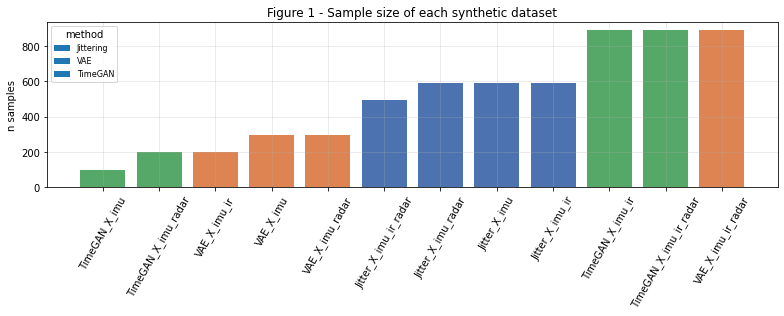

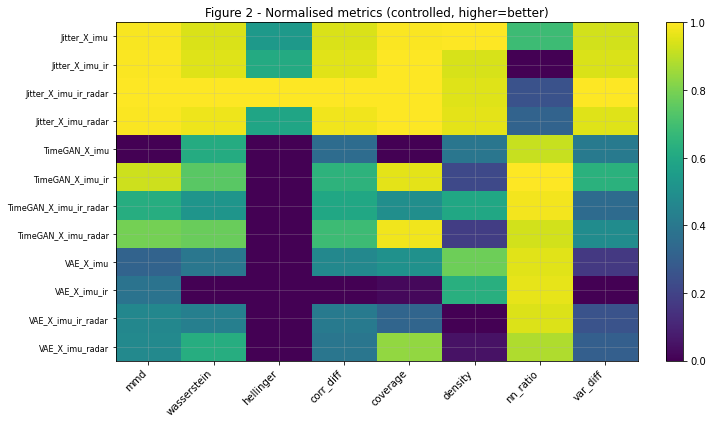

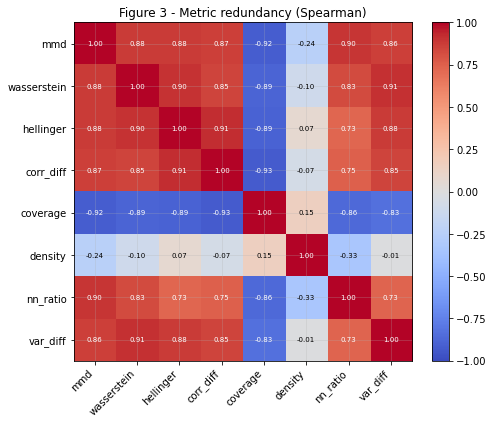

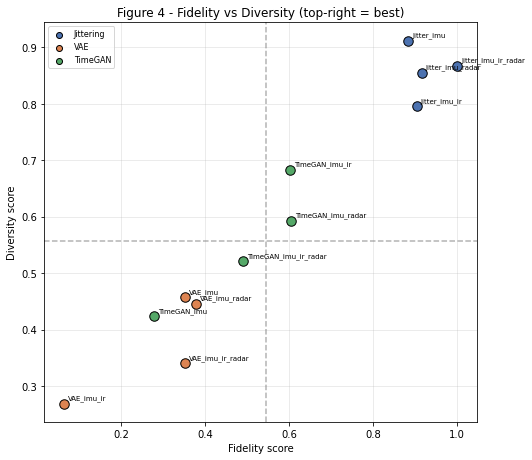

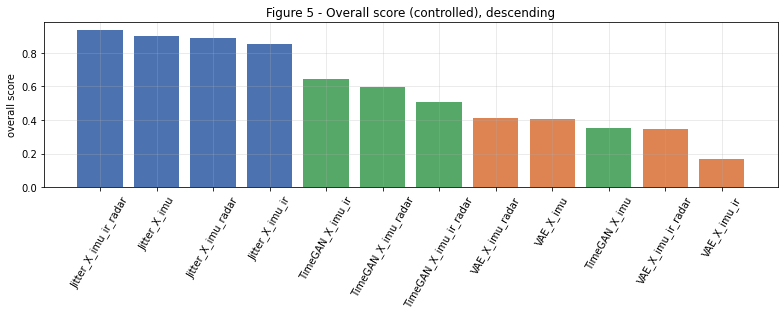

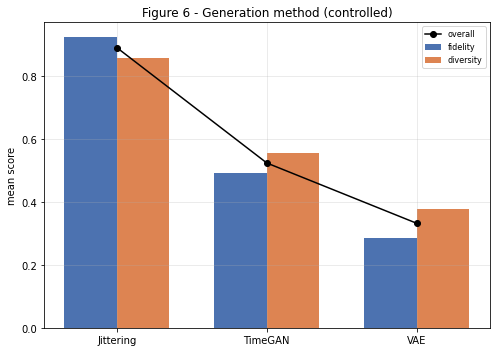

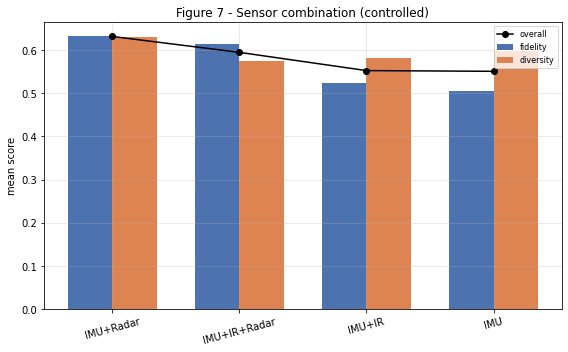

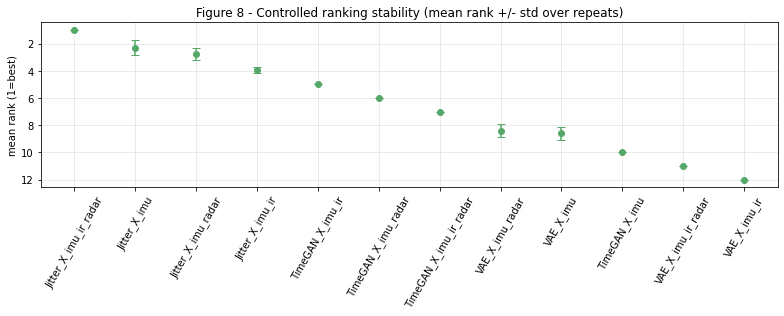

Saved 8 figures to /voc/work/evaluation_and_comparison/post_evaluation_output/post_evaluation_figures


In [19]:
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "axes.grid": True, "grid.alpha": 0.3})
def _save(fig, fn): fig.tight_layout(); fig.savefig(FIG_DIR / fn, bbox_inches="tight"); plt.show(); plt.close(fig)
PALETTE = {"Jittering":"#4C72B0","VAE":"#DD8452","TimeGAN":"#55A868"}

# Fig 1 - sample sizes
fig, ax = plt.subplots(figsize=(11,4.5))
d = FULL_RAW.sort_values("n_synth")
ax.bar(d["name"], d["n_synth"], color=[PALETTE.get(x,"#888") for x in d["method_label"]])
ax.set_title("Figure 1 - Sample size of each synthetic dataset"); ax.set_ylabel("n samples")
ax.tick_params(axis="x", rotation=60)
for lbl,c in PALETTE.items(): ax.bar([],[],color=c,label=lbl)
ax.legend(title="method", fontsize=8); _save(fig, "fig1_sample_sizes.png")

# Fig 2 - normalized metric heatmap (controlled)
fig, ax = plt.subplots(figsize=(10,6))
H = CONTROLLED_SCORED.set_index("name")[[f"n_{m}" for m in ALL_METRICS]]
im = ax.imshow(H.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(ALL_METRICS))); ax.set_xticklabels(ALL_METRICS, rotation=45, ha="right")
ax.set_yticks(range(len(H))); ax.set_yticklabels(H.index, fontsize=8)
ax.set_title("Figure 2 - Normalised metrics (controlled, higher=better)"); fig.colorbar(im, fraction=0.03)
_save(fig, "fig2_metric_heatmap.png")

# Fig 3 - metric correlation heatmap
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(MET_CORR.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(ALL_METRICS))); ax.set_xticklabels(ALL_METRICS, rotation=45, ha="right")
ax.set_yticks(range(len(ALL_METRICS))); ax.set_yticklabels(ALL_METRICS)
for i in range(len(ALL_METRICS)):
    for j in range(len(ALL_METRICS)):
        v = MET_CORR.values[i,j]
        if np.isfinite(v): ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=7,
                                    color="white" if abs(v)>0.6 else "black")
ax.set_title("Figure 3 - Metric redundancy (Spearman)"); fig.colorbar(im, fraction=0.046)
_save(fig, "fig3_metric_correlation.png")

# Fig 4 - fidelity vs diversity scatter (controlled)
fig, ax = plt.subplots(figsize=(7.5,6.5))
for _, r in CONTROLLED_SCORED.iterrows():
    ax.scatter(r["fidelity"], r["diversity"], s=90, color=PALETTE.get(r["method_label"],"#888"),
               edgecolor="k", zorder=3)
    ax.annotate(r["name"].replace("X_",""), (r["fidelity"], r["diversity"]), fontsize=7,
                xytext=(4,4), textcoords="offset points")
ax.axhline(CONTROLLED_SCORED["diversity"].median(), ls="--", color="grey", alpha=.6)
ax.axvline(CONTROLLED_SCORED["fidelity"].median(), ls="--", color="grey", alpha=.6)
ax.set_xlabel("Fidelity score"); ax.set_ylabel("Diversity score")
ax.set_title("Figure 4 - Fidelity vs Diversity (top-right = best)")
for lbl,c in PALETTE.items(): ax.scatter([],[],color=c,edgecolor="k",label=lbl)
ax.legend(fontsize=8); _save(fig, "fig4_fidelity_vs_diversity.png")

# Fig 5 - overall ranking (controlled)
fig, ax = plt.subplots(figsize=(11,4.5))
d = CONTROLLED_SCORED.sort_values("overall", ascending=False)
ax.bar(d["name"], d["overall"], color=[PALETTE.get(x,"#888") for x in d["method_label"]])
ax.set_title("Figure 5 - Overall score (controlled), descending"); ax.set_ylabel("overall score")
ax.tick_params(axis="x", rotation=60); _save(fig, "fig5_overall_ranking.png")

# Fig 6 - generation method comparison
fig, ax = plt.subplots(figsize=(7,5))
g = GEN_METHOD_RANKING
x = np.arange(len(g)); w=0.35
ax.bar(x-w/2, g["mean_fidelity"], w, label="fidelity", color="#4C72B0")
ax.bar(x+w/2, g["mean_diversity"], w, label="diversity", color="#DD8452")
ax.plot(x, g["mean_overall"], "ko-", label="overall")
ax.set_xticks(x); ax.set_xticklabels(g["method"]); ax.set_ylabel("mean score")
ax.set_title("Figure 6 - Generation method (controlled)"); ax.legend(fontsize=8)
_save(fig, "fig6_method_comparison.png")

# Fig 7 - sensor combination comparison
fig, ax = plt.subplots(figsize=(8,5))
s = SENSOR_RANKING
x = np.arange(len(s)); w=0.35
ax.bar(x-w/2, s["mean_fidelity"], w, label="fidelity", color="#4C72B0")
ax.bar(x+w/2, s["mean_diversity"], w, label="diversity", color="#DD8452")
ax.plot(x, s["mean_overall"], "ko-", label="overall")
ax.set_xticks(x); ax.set_xticklabels(s["sensors"], rotation=15); ax.set_ylabel("mean score")
ax.set_title("Figure 7 - Sensor combination (controlled)"); ax.legend(fontsize=8)
_save(fig, "fig7_sensor_comparison.png")

# Fig 8 - ranking stability (mean rank +/- std)
fig, ax = plt.subplots(figsize=(11,4.5))
d = STABILITY.sort_values("mean_rank")
ax.errorbar(range(len(d)), d["mean_rank"], yerr=d["rank_std"], fmt="o", capsize=4, color="#55A868")
ax.set_xticks(range(len(d))); ax.set_xticklabels(d["name"], rotation=60)
ax.invert_yaxis(); ax.set_ylabel("mean rank (1=best)")
ax.set_title("Figure 8 - Controlled ranking stability (mean rank +/- std over repeats)")
_save(fig, "fig8_ranking_stability.png")
print("Saved 8 figures to", FIG_DIR)

## 20. Export results

In [20]:
CONTROLLED_RAW.to_csv(RESULTS_DIR / "controlled_raw_per_repeat.csv", index=False)
CONTROLLED_SCORED.to_csv(RESULTS_DIR / "controlled_evaluation_results.csv", index=False)
FULL_SCORED.to_csv(RESULTS_DIR / "full_size_evaluation_results.csv", index=False)
MET_CORR.to_csv(RESULTS_DIR / "metric_correlation_matrix.csv")
DATASET_RANKING.to_csv(RESULTS_DIR / "dataset_ranking.csv", index=False)
GEN_METHOD_RANKING.to_csv(RESULTS_DIR / "generation_method_ranking.csv", index=False)
SENSOR_RANKING.to_csv(RESULTS_DIR / "sensor_combination_ranking.csv", index=False)
STABILITY.to_csv(RESULTS_DIR / "ranking_stability.csv", index=False)
FINAL.to_csv(RESULTS_DIR / "post_evaluation_results.csv", index=False)
DISCRIM.to_csv(RESULTS_DIR / "metric_discrimination.csv", index=False)
print("Wrote CSVs to", RESULTS_DIR)
for f in sorted(RESULTS_DIR.glob("*.csv")): print("  ", f.name)

Wrote CSVs to /voc/work/evaluation_and_comparison/post_evaluation_output
   controlled_evaluation_results.csv
   controlled_raw_per_repeat.csv
   dataset_metadata.csv
   dataset_ranking.csv
   full_size_evaluation_results.csv
   generation_method_ranking.csv
   metric_correlation_matrix.csv
   metric_discrimination.csv
   post_evaluation_results.csv
   ranking_stability.csv
   sensor_combination_ranking.csv


## 21. Interpretation report

Auto-generated from the computed values, distinguishing **evidence** (measured) from **inference** (judgement). No definitive model claims.

In [21]:
def _fmt(x): return f"{x:.3f}" if np.isfinite(x) else "NaN"
lines = []
top = FINAL.iloc[0]
best_fid = CONTROLLED_SCORED.loc[CONTROLLED_SCORED["fidelity"].idxmax()]
best_div = CONTROLLED_SCORED.loc[CONTROLLED_SCORED["diversity"].idxmax()]
gm = GEN_METHOD_RANKING.iloc[0]; sr = SENSOR_RANKING.iloc[0]
size_corr = FINAL[["full_N","overall_score"]].corr(method="spearman").iloc[0,1]

lines.append("="*78)
lines.append("POST-EVALUATION INTERPRETATION  (evidence vs inference)")
lines.append("="*78)
lines.append(f"\nQ1. Highest overall (controlled) score:")
lines.append(f"    {top['dataset']} ({top['generation_method']} + {top['sensors']}) — overall "
             f"{_fmt(top['overall_score'])}, full-size {_fmt(top['overall_full_size'])}, "
             f"top-3 stability {_fmt(top['top3_stability_%'])}%.")
lines.append(f"\nQ2. Strongest fidelity: {best_fid['name']} (fidelity {_fmt(best_fid['fidelity'])}).")
lines.append(f"Q3. Strongest diversity: {best_div['name']} (diversity {_fmt(best_div['diversity'])}).")
lines.append(f"\nQ4. Best generation method (controlling for sensor combo): {gm['method']} "
             f"— mean rank-in-combo {_fmt(gm['mean_rank_in_combo'])}, mean overall {_fmt(gm['mean_overall'])}, "
             f"wins {int(gm['wins'])}/{len(COMBO_KEYS)} combos.")
lines.append(f"Q5. Best sensor combination (averaged over methods): {sr['sensors']} "
             f"— mean overall {_fmt(sr['mean_overall'])} (best single: {sr['best_method']}).")
lines.append(f"\nQ6. Sample-size influence: Spearman(full_N, overall_score) = {_fmt(size_corr)}. "
             + ("Little evidence that raw quantity drives the ranking."
                if abs(size_corr) < 0.4 else
                "Quantity and score are correlated — interpret with care (reported separately, not merged)."))
lines.append(f"\nQ7. Top dataset stability: {top['dataset']} held top-3 in {_fmt(top['top3_stability_%'])}% "
             f"of {N_REPEATS} controlled repeats (rank std {_fmt(top['rank_stability_std'])}).")
proceed = FINAL[FINAL["recommendation"].isin(["Highest Priority","High Priority"])]
lines.append(f"\nQ8. Recommended to proceed ({len(proceed)}):")
for _, r in proceed.iterrows():
    lines.append(f"    - {r['dataset']} [{r['recommendation']}] overall {_fmt(r['overall_score'])}, "
                 f"full_N {int(r['full_N'])}, top-3 {_fmt(r['top3_stability_%'])}%")
lines.append("\n" + "-"*78)
lines.append("DISTINCTIONS (do not conflate):")
lines.append(f"  best individual dataset : {top['dataset']}")
lines.append(f"  best generation method  : {gm['method']}")
lines.append(f"  best sensor combination : {sr['sensors']}")
lines.append("-"*78)
lines.append("Framing: values are 'highest under this evaluation procedure', not proof one generator is "
             "universally best. Small real N (~99) and high feature dims make every metric approximate; "
             "controlled and full-size analyses answer different questions and are reported separately.")
report = "\n".join(lines)
print(report)
(RESULTS_DIR / "interpretation_report.txt").write_text(report)

POST-EVALUATION INTERPRETATION  (evidence vs inference)

Q1. Highest overall (controlled) score:
    Jitter_X_imu_ir_radar (Jittering + IMU+IR+Radar) — overall 0.934, full-size 0.930, top-3 stability 100.000%.

Q2. Strongest fidelity: Jitter_X_imu_ir_radar (fidelity 1.000).
Q3. Strongest diversity: Jitter_X_imu (diversity 0.912).

Q4. Best generation method (controlling for sensor combo): Jittering — mean rank-in-combo 1.000, mean overall 0.892, wins 4/4 combos.
Q5. Best sensor combination (averaged over methods): IMU+Radar — mean overall 0.632 (best single: Jittering).

Q6. Sample-size influence: Spearman(full_N, overall_score) = 0.317. Little evidence that raw quantity drives the ranking.

Q7. Top dataset stability: Jitter_X_imu_ir_radar held top-3 in 100.000% of 20 controlled repeats (rank std 0.000).

Q8. Recommended to proceed (3):
    - Jitter_X_imu_ir_radar [Highest Priority] overall 0.934, full_N 495, top-3 100.000%
    - Jitter_X_imu [Highest Priority] overall 0.898, full_N 59

1847

### Notes, caveats & references

* **Two questions, never merged.** Controlled-size (Analysis A) = fair method comparison at a common
  synthetic N per combo; full-size (Analysis B) = practical quality at native N. The final table shows both.
* **Anti-double-counting.** Correlated distributional metrics (MMD/Wasserstein/Hellinger) share one 50%
  fidelity sub-slot; coverage/density/NN share one 50% diversity sub-slot. Category weights are equal and
  configurable; no p-value-based weighting is used.
* **Small-sample honesty.** `N < SMALL_SAMPLE_MIN` yields `NaN` (never a faked 0); `N < SMALL_SAMPLE_WARN`
  is computed but flagged, and such datasets are marked unstable in the final ranking.
* **Representation.** Distributional/geometry metrics use a real-fit standardized-PCA embedding of the
  flattened `T*F` sequence; Wasserstein/correlation/variance use standardized per-channel (marginal) views.
  Neither is claimed to fully capture temporal fidelity.
* **Reference.** El Emam K, Mosquera L, Fang X, El-Hussuna A. *Utility Metrics for Evaluating Synthetic
  Health Data Generation Methods: Validation Study.* JMIR Med Inform. 2022;10(4):e35734.
  doi:10.2196/35734 — general support for metric-based ranking of SDG methods and the slight Hellinger
  advantage in **their** structured-health-data setting; not a validation for QUIDA/time-series/fall
  detection.